# Computing for Economists: Bandit Problems and Reinforcement Learning

In [1]:
!pip install gymnasium==0.29.1
!pip install 'gymnasium[toy-text]'
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from IPython.display import clear_output

zsh:1: command not found: pip
zsh:1: command not found: pip


## Multi-Armed Bandits


Consider a $k$-armed bandit problem with $k=10$ arms. We will initialize the true rewards as $q_*(a) \sim \mathcal N(0, 1)$ for $a \in \{1, 2, ..., 10\}$. When the agent selects action $A_t$ in period $t$, the reward the agent receives is then drawn from a normal distribution with mean $q_*(A_t)$ and variance 1.


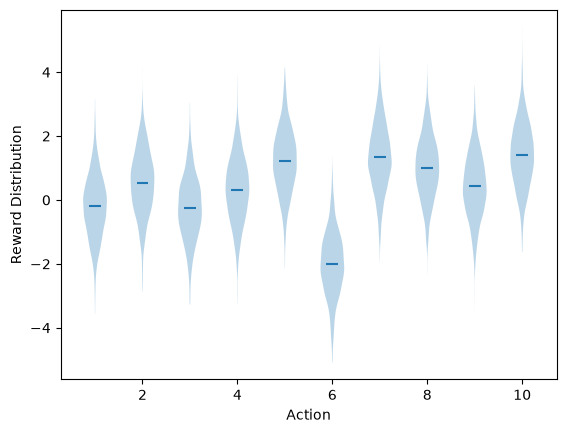

In [2]:
values = np.random.normal(size=(10, ))
data = [np.random.normal(value, 1.0, 2000) for value in values]
plt.violinplot(
    dataset=data,
    showextrema=False,
    showmeans=True,
    points=2000
)
plt.xlabel('Action')
plt.ylabel('Reward Distribution')
plt.show()

Below we implement a class called `SimpleBandit` that implements the solutions we have seen.

In [3]:
class SimpleBandit:
    def __init__(
            self,
            k=10,
            q_mean=0,
            initial_val=0,
            epsilon=0,
            step_size=0.1,
            sample_average=False,
            UCB_param=0,
    ):
      """
      Initialize a simple `k`-armed bandit problem.

      Parameters
      ----------
      k : int, default = 10
          Number of arms.
      q_mean : float or array_like of length `k`, default = 0
          True mean of each arm.
      initial_val : float or array_like of length `k`, default = 0
          Initial value for each arm.
      epsilon : float, default = 0
          Probability of selecting a random action.
      step_size : float, default = 0.1
          Constant step size for updating estimations.
      sample_average : bool, default = False
          If True, use sample averages to update estimations instead of constant
          step size.
      UCB_param : float, default = 0
          Parameter for UCB algorithm. If 0, uses epsilon-greedy algorithm.
      """
      self.k = k
      self.arms = np.arange(self.k)
      self.q_mean = q_mean
      self.initial_val = initial_val
      self.epsilon = epsilon
      self.step_size = step_size
      self.sample_average = sample_average
      self.UCB_param = UCB_param
      self.reset()

    def select_action(self):
      """Select an action."""
      if np.random.rand() < self.epsilon:
        # explore (non-greedy action)
        action = np.random.choice(self.arms)
      else:
        # exploit (greedy action)
        UCB_term = self.UCB_param * np.sqrt(np.log(self.period + 1) / (self.action_count + 1e-6))
        est = self.Q + UCB_term
        action = np.random.choice(np.flatnonzero(est == est.max()))
      return action

    def step(self, action):
      """
      Update the estimation.

      Parameters
      ----------
      action : int
          Selected action.
      """
      # draw the reward from reward distribution
      reward = np.random.normal(self.q_true[action], 1)
      # time updates
      self.period += 1
      self.action_count[action] += 1

      if self.sample_average:
        self.Q[action] += (reward - self.Q[action]) / self.action_count[action]
      else:
        # update w/ (constant) step size
        self.Q[action] += self.step_size * (reward - self.Q[action])
      return reward

    def reset(self):
      """Reset the bandit."""
      self.period = 0
      self.q_true = np.random.normal(self.q_mean, 1, self.k)
      self.Q = self.initial_val * np.ones(self.k)
      self.action_count = np.zeros(self.k)
      self.best_action = np.argmax(self.q_true)

    def simulate(self, runs, periods):
      """
      Simulate the bandit problem for a specified number of runs and
      periods per run.

      Parameters
      ----------
      runs : int
          Number of runs.
      periods : int
          Number of periods.

      Returns
      -------
      A tuple of two arrays of shape (periods,). The first array contains
      the average reward in each period across runs and the second contains the
      proportion of runs with the best action taken for each period.
      """
      rewards = np.zeros((runs, periods))
      best_action_chosen = np.zeros(rewards.shape)
      for i in range(runs):
        self.reset()
        for t in range(periods):
            action = self.select_action()
            reward = self.step(action)
            rewards[i, t] = reward
            if action == self.best_action:
                best_action_chosen[i, t] = 1
      mean_rewards = np.mean(rewards, axis=0)
      mean_best_action = np.mean(best_action_chosen, axis=0)
      return mean_rewards, mean_best_action


1. <font color = 'purple'> [AI Edit & Design Tests]</font> Compare the greedy method ($\varepsilon$ = 0) with an $\varepsilon$-greedy method where $\varepsilon$ = 0.01, setting $Q_1(a) = \mathbb E[q_*(a)] = 0$ for all actions. For each method, repeat the process for 1,000 independent runs, each with 1,000 periods. Plot the average reward and the proportion of times the best action was taken for each period.

In [2]:
# Solution
bandit = SimpleBandit(epsilon=0)
rewards_greedy, best_action_greedy = bandit.simulate(1000, 1000)

bandit = SimpleBandit(epsilon=0.01)
rewards_eps, best_action_eps = bandit.simulate(1000, 1000)

# For illustration, also run a larger epsilon.
bandit = SimpleBandit(epsilon=0.1)
rewards_eps10, best_action_eps10 = bandit.simulate(1000, 1000)

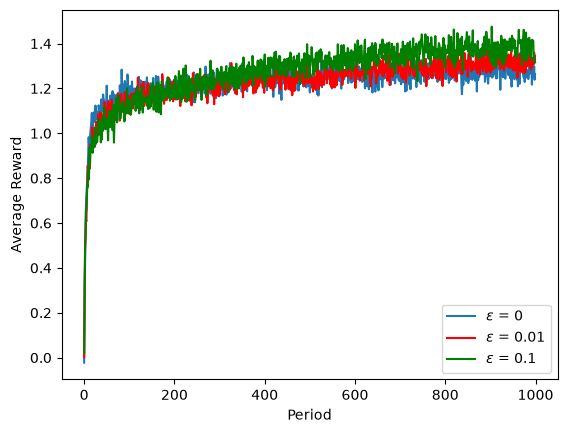

In [3]:
# Solution
ax = sns.lineplot(rewards_greedy, label='$\epsilon$ = 0')
sns.lineplot(rewards_eps, color='red', label='$\epsilon$ = 0.01')
sns.lineplot(rewards_eps10, color='green', label='$\epsilon$ = 0.1')
ax.set(xlabel='Period', ylabel='Average Reward')
plt.show()

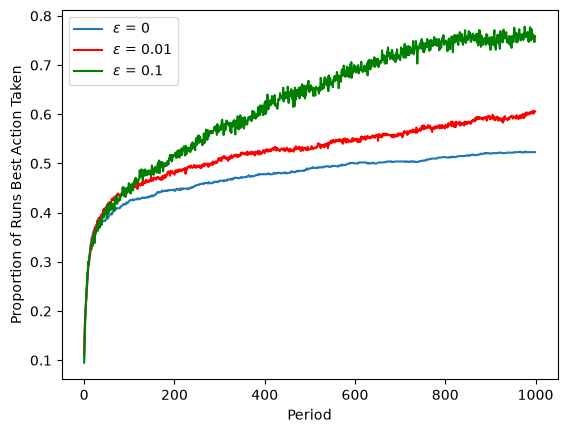

In [4]:
# Solution
ax = sns.lineplot(best_action_greedy, label='$\epsilon$ = 0')
sns.lineplot(best_action_eps, color='red', label='$\epsilon$ = 0.01')
sns.lineplot(best_action_eps10, color='green', label='$\epsilon$ = 0.1')
ax.set(xlabel='Period', ylabel='Proportion of Runs Best Action Taken')
plt.show()

2. <font color = '701B1B'> [Conceptual]</font> The performance of the greedy approach to solving multi-armed bandit problems depends on the initial action-value estimates, $Q_1(a)$. Set $Q_1(a) = 5$ for all actions and $\varepsilon = 0$. Compare the results to those in part 1 of this problem. Which method performed best? Why did this method perform best over 1,000 periods? Did the best method encourage more exploration or exploitation? Do you expect this method to remain ahead over longer time horizons?


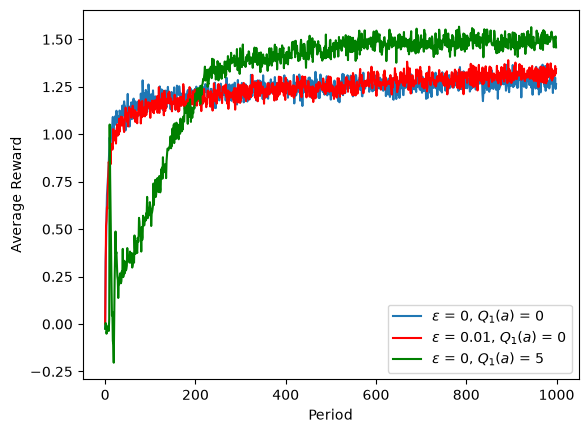

In [5]:
# Solution
bandit = SimpleBandit(initial_val=5, epsilon=0)
rewards_optimistic, best_action_optimistic = bandit.simulate(1000, 1000)

ax = sns.lineplot(rewards_greedy, label='$\epsilon$ = 0, $Q_1(a)$ = 0')
sns.lineplot(rewards_eps, color='red', label='$\epsilon$ = 0.01, $Q_1(a)$ = 0')
sns.lineplot(rewards_optimistic, color='green', label='$\epsilon$ = 0, $Q_1(a)$ = 5')
ax.set(xlabel='Period', ylabel='Average Reward')
plt.show()

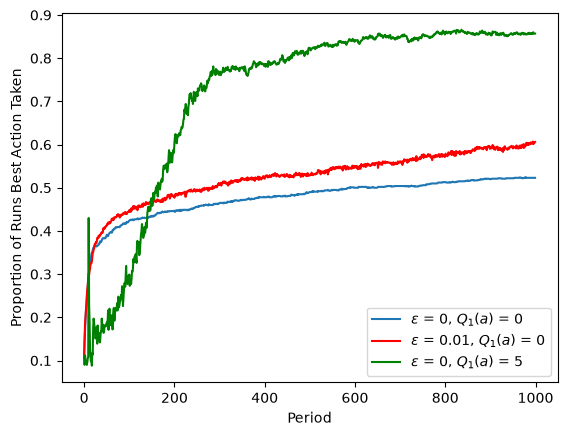

In [6]:
# Solution
ax = sns.lineplot(best_action_greedy, label='$\epsilon$ = 0, $Q_1(a)$ = 0')
sns.lineplot(best_action_eps, color='red', label='$\epsilon$ = 0.01, $Q_1(a)$ = 0')
sns.lineplot(best_action_optimistic, color='green', label='$\epsilon$ = 0, $Q_1(a)$ = 5')
ax.set(xlabel='Period', ylabel='Proportion of Runs Best Action Taken')
plt.show()

***Solution:*** The optimistic greedy method ($Q_1(a)=5$, $\varepsilon=0$) does best over the 1,000 periods. Because the initial estimates (5) far exceed the true values (mean 0), every arm disappoints the greedy agent at first, so it keeps switching. The optimism forces broad early exploration even with $\varepsilon=0$. Once the estimates fall to realistic levels it settles on the best arm and exploits it. So it encourages exploration, but only temporarily.

Over longer horizons, however, we should *not* expect it to stay ahead. The drive to explore here is transient: once the inflated estimates have deflated, the agent is purely greedy and has no mechanism left for sampling arms it has abandoned. Under sample-average updates the step size $1/n$ shrinks toward zero, so an arm that stops being pulled keeps a stale estimate forever and the agent can lock onto a suboptimal arm permanently. Optimistic greedy therefore *plateaus* at some rate of optimal-action selection strictly below 100%.

$\varepsilon$-greedy does keep taking a random arm a fraction $\varepsilon$ of the time, so it is capped — but the cap is $(1-\varepsilon) + \varepsilon/k$, which for $\varepsilon = 0.01$ and $k = 10$ equals $99.1\%$. That is *higher* than the level optimistic greedy settles at. Because every arm is still sampled at least $\varepsilon/k$ of the time, the $\varepsilon$-greedy estimates keep converging and it keeps improving, so it eventually catches and passes the optimistic method. The right summary is that optimistic initial values buy excellent *early* performance — which is exactly what the 1,000-period figure shows — not a better asymptote.

Note that this comparison depends on $\varepsilon$ being small. At $\varepsilon = 0.1$ the cap is only $91\%$, which is comparable to where optimistic greedy plateaus.

Finally, the trick would not help at all on a nonstationary problem, where the arms drift and sustained exploration is needed.

## Learning to Drive a Taxi with $Q$-Learning

Consider the following toy environment, which comes from `gymnasium` library (formerly the [OpenAI Gym](https://arxiv.org/pdf/1606.01540)).
**Note**: we are using `gymnasium` version `0.29.1`. The starter code we have provided may not be compatible with other versions of the library.

There are four designated taxi pick up and drop off locations. When an episode (ride) starts, the taxi starts off at a random square and the passenger is at a random location. The goal is to train the traxi to drive to the passenger's location, pick up the passenger, drive to the passenger's destination (another one of the four specified locations), and then drop off the passenger. Once the passenger is dropped off, the episode ends. There is a reward for a successful drop-off, a penalty for picking up or dropping off in the wrong place, and a travel cost.

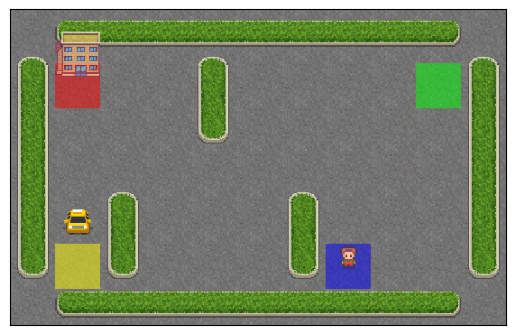

In [ ]:
env = gym.make("Taxi-v3", render_mode="rgb_array")
env.reset()
plt.imshow(env.render())
plt.xticks([])
plt.yticks([])
plt.show()



### Action Space

The action shape is `(1,)` in the range `{0, 5}` indicating which direction to move the taxi or to pickup/drop off passengers.

- 0: Move south (down)
- 1: Move north (up)
- 2: Move east (right)
- 3: Move west (left)
- 4: Pickup passenger
- 5: Drop off passenger

### Observation Space

There are 500 discrete states since there are 25 taxi positions, 5 possible locations of the passenger (including the case when the passenger is in the taxi), and 4 destination locations.

Destinations on the map are represented by colors when `render_mode == "rgb_array"` and by the first letter of the color when `render_mode == "ansi"`.

Passenger locations:

- 0: Red
- 1: Green
- 2: Yellow
- 3: Blue
- 4: In taxi

Destinations:

- 0: Red
- 1: Green
- 2: Yellow
- 3: Blue


### Rewards
- -1 per step unless other reward is triggered.
- +20 delivering passenger.
- -10 executing “pickup” and “drop-off” actions illegally.

1. <font color='red'> [Write it yourself]</font> Initialize the environment and move north for five steps. For each step, display the cumulative reward and the location of the taxi in the environment. What happens when the taxi gets stuck?

In [ ]:
def display_env(env):
  """Helper function to display the environment."""
  if env.render_mode == "rgb_array":
    plt.imshow(env.render())
    plt.xticks([])
    plt.yticks([])
    plt.show()
  elif env.render_mode == "ansi":
    print(env.render())
  else:
    raise ValueError(f"Render mode {env.render_mode} not supported.")


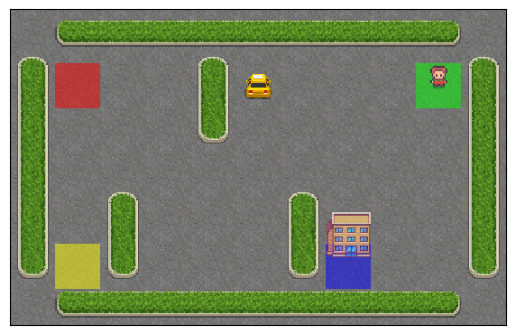

In [ ]:
# Solution:
env.reset()
num_steps = 5
display_env(env)
cumulative_reward = 0
for s in range(1, num_steps+1):
    print(f"Step {s} of {num_steps}")
    action = 1
    new_state, reward, done, _, _ = env.step(action)
    cumulative_reward += reward
    print(f"Cumulative Reward: {cumulative_reward}")
    # print the new state
    clear_output(wait=True)
    display_env(env)
    time.sleep(2)

Below we provide the skeleton for a class called `QAgent`, which takes in a `gymnasium` environment and hyperparameters and trains a $Q$-learning agent.

2. <font color='red'> [Write it yourself]</font> Fill in the remaining code and train a taxi agent for 20,000 episodes, with a maximum of 100 steps (periods) per episode. Evaluate the performance by running the method `evaluate()` for different random initializations of the environment.

In [ ]:
# hyperparamters
learning_rate = 0.1
discount_rate = 0.8
epsilon = 0.9 # initial epsilon
decay = 0.99 # rate at which epsilon decays

# training vars
num_episodes = 20000
max_steps = 100 # max steps per episode

In [ ]:
# Solution

class QAgent():
  """Q-Learning agent."""

  def __init__(self, env, learning_rate, discount_rate, epsilon, decay):
    """Initialize Q-Learning agent."""
    self.env = env
    self.learning_rate = learning_rate
    self.discount_rate = discount_rate
    self.epsilon = epsilon
    self.decay = decay

  def act(self, q_table, state):
    """Select an action."""
    if np.random.rand() < self.epsilon:
      # explore
      action = self.env.action_space.sample()
    else:
      # exploit
      action = np.argmax(q_table[state, :])
    return action

  def train(self, episodes, max_steps):
    """Train the agent."""
    state_size = self.env.observation_space.n
    action_size = self.env.action_space.n
    q_table = np.zeros((state_size, action_size))

    for episode in range(episodes):
      state, _ = self.env.reset()
      done = False

      for step in range(max_steps):
        action = self.act(q_table, state)
        new_state, reward, done, _, _ = self.env.step(action)

        # update q-table
        q_table[state, action] += self.learning_rate * (
            reward + self.discount_rate * np.max(q_table[new_state]) - q_table[state, action]
        )

        # update state
        state = new_state

        if done == True:
          break

      # Decay epsilon once per EPISODE, not once per step. `decay` is a
      # per-episode annealing rate, so applying it inside the step loop makes
      # the exploration budget be measured in steps rather than episodes:
      # 0.9 * 0.99**450 < 0.01, so epsilon would collapse within the first
      # handful of episodes of a 20,000-episode run and the agent would be
      # effectively greedy for essentially all of training. That cannot cover
      # the 500 x 6 = 3,000 state-action pairs Taxi-v3 needs visited.
      # Decaying per episode also keeps the schedule independent of episode
      # length, which itself shrinks as the agent improves.
      self.epsilon *= self.decay

    self.q_table = q_table


  def evaluate(self, display_delay=2):
    """Evaluate the agent."""
    state, _ = self.env.reset()
    display_env(self.env)
    done = False
    rewards = 0

    for s in range(1, max_steps+1):
      print(f"Step {s}")
      action = np.argmax(self.q_table[state,:])
      new_state, reward, done, _, _ = self.env.step(action)
      rewards += reward
      print(f"Cumulative Reward: {rewards}")
      clear_output(wait=True)
      display_env(self.env)
      state = new_state
      time.sleep(display_delay)

      if done == True:
          break

q_agent = QAgent(env, learning_rate, discount_rate, epsilon, decay)
q_agent.train(num_episodes, max_steps)
q_agent.evaluate()

<font color = 'purple'> [AI Edit & Design Tests]</font> Try using the `QAgent` to train an agent in another environment (e.g., in the [Frozen Lake](https://gymnasium.farama.org/environments/toy_text/frozen_lake/) environment).